In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path.cwd().parent
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'

# Load master table
master = pd.read_csv(DATA_PROCESSED / 'master.csv')
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])
master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'])

# Load reviews separately — it's not in master
reviews = pd.read_csv(DATA_RAW / 'olist_order_reviews_dataset.csv')

print(f"master:  {master.shape[0]:,} rows")
print(f"reviews: {reviews.shape[0]:,} rows")

master:  110,197 rows
reviews: 99,224 rows


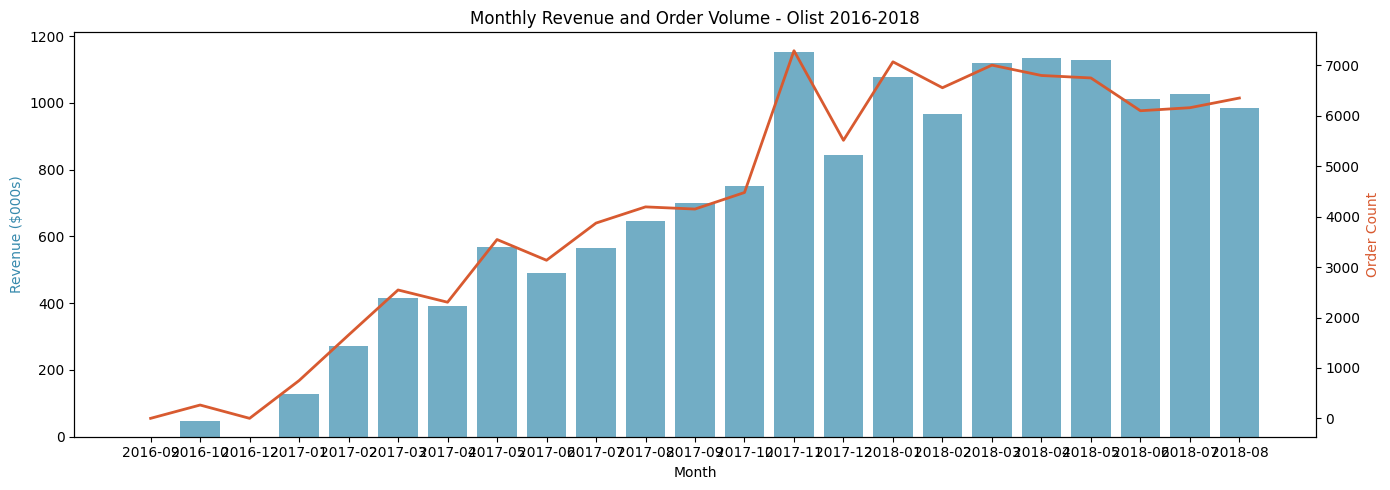

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly=(master.groupby('order_month')
          .agg(revenue=('revenue','sum'),orders=('order_id','nunique'))
          .reset_index())

monthly['order_month']=monthly['order_month'].astype(str)

fig,ax1=plt.subplots(figsize=(14,5))
ax2=ax1.twinx()

ax1.bar(monthly['order_month'], monthly['revenue']/1000,
        color='#378AAD',alpha=0.7, label='Revenue ($k)')
ax2.plot(monthly['order_month'],monthly['orders'],
        color="#D85A30",linewidth=2,label='Order count')


ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($000s)', color="#378AAD")
ax2.set_ylabel('Order Count', color="#D85A30")
plt.xticks(rotation=45,ha='right')
plt.title('Monthly Revenue and Order Volume - Olist 2016-2018')
plt.tight_layout()
plt.savefig('../reports/figures/monthly_revenue_orders.png', dpi=150, bbox_inches='tight')

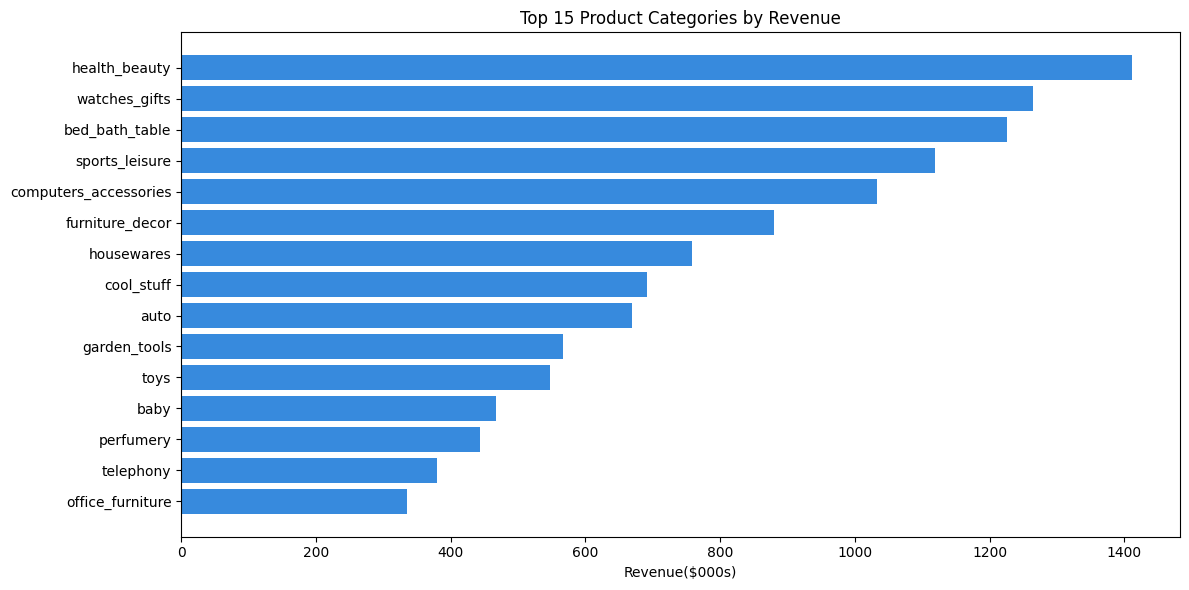

In [9]:
cat_revenue=(master.groupby('product_category_name_english')
             .agg(revenue=('revenue','sum'), orders=('order_id','nunique'))
             .reset_index()
             .sort_values('revenue', ascending=False)
             .head(15))

plt.figure(figsize=(12,6))
bars = plt.barh(cat_revenue['product_category_name_english'],
              cat_revenue['revenue']/1000,
              color='#378ADD')

plt.xlabel('Revenue($000s)')
plt.title('Top 15 Product Categories by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_categories_revenue.png', dpi=150, bbox_inches='tight')

On-time delivery rate: 92.3%


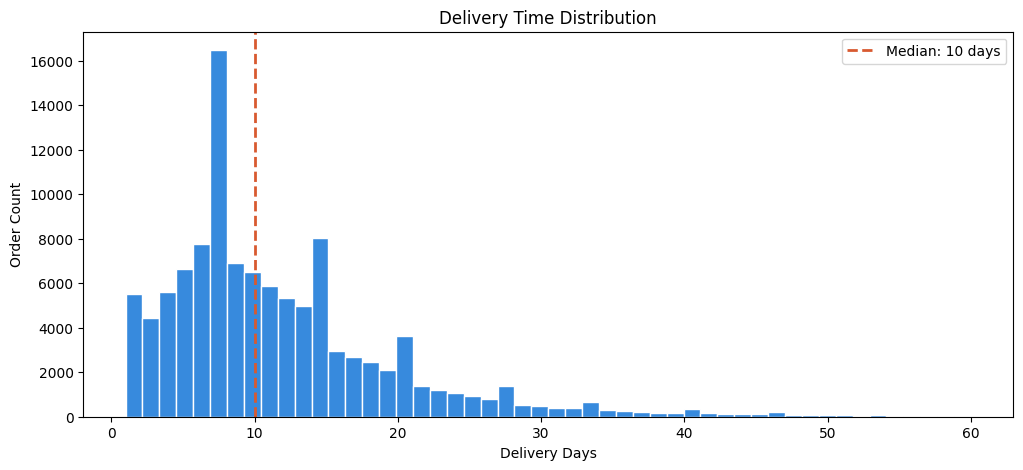

In [12]:
#Distribution of delivery times
delivered_clean=master[master['delivery_days'].between(1,60)].copy()

plt.figure(figsize=(12,5))
plt.hist(delivered_clean['delivery_days'], bins=50, color='#378ADD', edgecolor='white')
plt.axvline(delivered_clean['delivery_days'].median(),color='#D85A30',linestyle='--',linewidth=2,label=f"Median: {delivered_clean['delivery_days'].median():.0f} days")
plt.xlabel('Delivery Days')
plt.ylabel('Order Count')
plt.title('Delivery Time Distribution')
plt.legend()
plt.savefig('../reports/figures/delivery_time_distribution.png', dpi=150, bbox_inches='tight')

#On-time delivery rate
delivered_clean['on_time'] = delivered_clean['order_delivered_customer_date'] <= delivered_clean['order_estimated_delivery_date']
on_time_rate = delivered_clean['on_time'].mean() * 100
print(f"On-time delivery rate: {on_time_rate:.1f}%")


In [16]:
avg_score_by_cat=(master.merge(
    reviews[['order_id','review_score']],on='order_id',how='left')
    .groupby('product_category_name_english')['review_score']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'avg_score','count':'review_count'})
    .query('review_count >= 100')
    .sort_values('avg_score',ascending=False)
)

print('Top rated categories:')
print(avg_score_by_cat.head(10).to_string(index=False))

print('Lowest rated categories:')
print(avg_score_by_cat.tail(10).to_string(index=False))

Top rated categories:
product_category_name_english  avg_score  review_count
       books_general_interest   4.512195           533
              books_technical   4.393939           264
                   food_drink   4.369004           271
          luggage_accessories   4.352283          1073
                fashion_shoes   4.285156           256
                         food   4.262834           487
            furniture_bedroom   4.252427           103
                   stationery   4.244002          2459
              home_appliances   4.225602           789
             small_appliances   4.225266           657
Lowest rated categories:
product_category_name_english  avg_score  review_count
    construction_tools_safety   3.967033           182
            home_construction   3.959528           593
              furniture_decor   3.950116          8159
        furniture_living_room   3.937247           494
               bed_bath_table   3.920983         10985
                 h